In [42]:
import numpy as np
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import minimize


## Model Definition

In [43]:
class ControlMenstrualModel:
    def __init__(self, 
                 compartments=None, 
                 initial_hormones=None,
                 time_domain=(0, 1),
                 resolution=100,
                 parameters=None):
        """
        compartments: list of compartment names
        initial_hormones: dict with initial values for each compartment
        time_domain: tuple (t0, tf)
        resolution: number of time points
        parameters: nested dictionary of synthesis, clearance, and regulatory parameters
        """
        # Default compartments
        self.compartments = ['GnRH', 'LH', 'Estrogen'] if compartments is None else compartments
        self.compartment_to_index = {name: i for i, name in enumerate(self.compartments)}
        
        # Time domain
        self.time_domain = time_domain
        self.resolution = resolution
        self.t = np.linspace(time_domain[0], time_domain[1], resolution)
        
        # Parameters
        self.params = self._create_default_params() if parameters is None else self._create_default_params() | parameters
        
        # Initial hormone values
        if not isinstance(initial_hormones, dict):
            raise ValueError("Need a dictionary of initial conditions")
        if set(self.compartments) != set(initial_hormones.keys()):
            raise ValueError(f"Compartments and initial conditions keys must match!\n"
                             f"Compartments: {self.compartments}\n"
                             f"Initial conditions: {list(initial_hormones.keys())}")
        self.y0 = self._create_initial_condition(**initial_hormones)
    
    def _create_initial_condition(self, **initial_hormones):
        y0 = np.zeros(len(self.compartments))
        for comp in self.compartments:
            y0[self.compartment_to_index[comp]] = initial_hormones[comp]
        return y0
    
    def unpack(self, y):
        """Return a dict mapping compartment names to values."""
        return {comp: y[self.compartment_to_index[comp]] for comp in self.compartments}
    
    def _create_default_params(self):
        """Return a default parameter dictionary."""
        return {
            'synthesis': {
                'GnRH': 2.44,
                'LH': 6.35,
                'Estrogen': 2.45
            },
            'clearance': {
                'GnRH': 0.17,
                'LH': 0.35,
                'Estrogen': 0.09
            },
            'regulatory': {
                ('Estrogen', 'GnRH'): {
                    'n': (10.00, 4.41),
                    'K': (0.16, 0.56)
                },
                ('GnRH', 'LH'): {
                    'n': (5.73, 9),
                    'K': (6.62, 11)
                },
                ('LH', 'Estrogen'): {
                    'n': (6.76, 10.00),
                    'K': (9.75, 20.25)
                }
            },
            'control': {
                'GnRH': 1,
                'LH': 1,
                'Estrogen': 1
            }
        }
    
    # Hill functions
    @staticmethod
    def hill_activate(K, n, P):
        P = np.maximum(P, 1e-12)
        K = np.maximum(K, 1e-12)
        n = np.maximum(n, 1e-12)

        Pn = np.exp(n * np.log(P))
        Kn = np.exp(n * np.log(K))

        return Pn / (Kn + Pn)


    @staticmethod
    def hill_repress(K, n, P):
        P = np.maximum(P, 1e-12)
        K = np.maximum(K, 1e-12)
        n = np.maximum(n, 1e-12)

        Pn = np.exp(n * np.log(P))
        Kn = np.exp(n * np.log(K))

        return Kn / (Kn + Pn)
    
    @staticmethod
    def hill_biphasic(K1, K2, n1, n2, P):
        return ControlMenstrualModel.hill_activate(K1, n1, P) * ControlMenstrualModel.hill_repress(K2, n2, P)
    
    def ode(self, t, y, u):
        h = self.unpack(y)
        GnRH, LH, Estrogen = h['GnRH'], h['LH'], h['Estrogen']
        uG, uL, uE = u

        #clamping the hormones to avoid numerical instability
        GnRH = max(GnRH, 1e-8)
        LH = max(LH, 1e-8)
        Estrogen = max(Estrogen, 1e-8)
        
        # ---------------- GnRH ----------------
        synth_E_on_GnRH = self.params['synthesis']['GnRH']
        clearance_GnRH = self.params['clearance']['GnRH']
        n_EGnRH1, n_EGnRH2 = self.params['regulatory'][('Estrogen', 'GnRH')]['n']
        K_EGnRH1, K_EGnRH2 = self.params['regulatory'][('Estrogen', 'GnRH')]['K']
        alphaG = self.params['control']['GnRH']
        
        dGnRH = (synth_E_on_GnRH * (self.hill_biphasic(K_EGnRH1, K_EGnRH2, n_EGnRH1, n_EGnRH2, Estrogen))
                 - clearance_GnRH * GnRH
                 + alphaG * uG)
        
        # ---------------- LH ----------------
        synth_LH_GnRH = self.params['synthesis']['LH']
        clearance_LH = self.params['clearance']['LH']
        n1_GLH, n2_GLH = self.params['regulatory'][('GnRH', 'LH')]['n']
        K1_GLH, K2_GLH = self.params['regulatory'][('GnRH', 'LH')]['K']
        alphaL = self.params['control']['LH']
        
        dLH = (synth_LH_GnRH * self.hill_biphasic(K1_GLH, K2_GLH, n1_GLH, n2_GLH, GnRH)
               - clearance_LH * LH
               + alphaL * uL)
        
        # ---------------- Estrogen ----------------
        synth_Estrogen = self.params['synthesis']['Estrogen']
        clearance_Estrogen = self.params['clearance']['Estrogen']
        n_L_E1, n_L_E2 = self.params['regulatory'][('LH', 'Estrogen')]['n']
        K_L_E1, K_L_E2 = self.params['regulatory'][('LH', 'Estrogen')]['K']
        alphaE = self.params['control']['Estrogen']
        
        dEstrogen = (synth_Estrogen * (self.hill_biphasic(K_L_E1, K_L_E2, n_L_E1, n_L_E2, LH))
                     - clearance_Estrogen * Estrogen
                     + alphaE * uE)
        
        return np.array([dGnRH, dLH, dEstrogen])
    
    def simulate(self, u, method='RK45'):
        """Simulate the ODE system over the time domain."""
        sol = solve_ivp(fun=self.ode, t_span=self.time_domain, y0=self.y0,
                        t_eval=self.t, method=method, args=(u, ))
        return sol
    
    
    def plot(self, sol, compartments=None, title="Menstrual Cycle Model", ylim=None, axis=None, plot_day_14 = False):
        axis = plt.gca() if axis == None else axis
        ylim = (0, 8) if ylim == None else ylim

        if compartments is None:
            compartments=self.compartments
        
        for name in compartments:
            if name not in self.compartments:
                raise ValueError(f"Trying to plot nonexistent compartment: {name}")
            i = self.compartment_to_index[name]

            axis.plot(sol.t, sol.y[i], label=name)
        
        if plot_day_14:
            axis.vlines(x=14, ymin=ylim[0], ymax=ylim[1], linestyles='--', colors='black')
        
        axis.set(xlabel='Days', ylabel='Hormone Concentrations', title=title, ylim=ylim)
        plt.legend(loc="upper right")

In [44]:
initial_conditions = {
    'GnRH': 1.0,
    'LH': 0.25,
    'Estrogen': 1.0
}

### helper functions

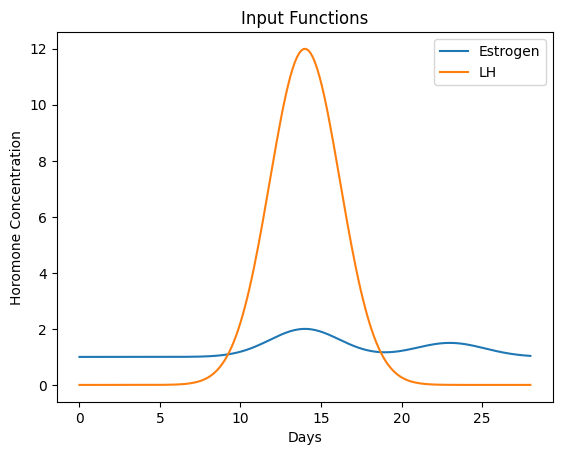

In [45]:
def plot_input_data(xlim = None, resolution = 200):
    xlim = (0, 28) if xlim == None else xlim
    estradiol_function = lambda x: 1 + 1 * np.exp(-(x-14)**2/(9.5)) + 0.5 * np.exp(-(x-23)**2/(9.5)) + 1 * np.exp(-(x-42)**2/(9.5))+ 0.5 * np.exp(-(x-51)**2/(9.5))
    LH_function = lambda x: 0 + 12 * np.exp(-(x-14)**2/(9.5)) + 12 * np.exp(-(x-42)**2/(9.5))
    x = np.linspace(xlim[0], xlim[1], resolution)
    plt.plot(x, estradiol_function(x), label='Estrogen')
    plt.plot(x, LH_function(x), label='LH')
    plt.gca().set(xlabel='Days', ylabel='Horomone Concentration', ylim=(0, 8), title='Input Functions')
    plt.autoscale(enable=True, axis='y', tight=False)
    plt.legend()

plot_input_data()

In [46]:
def unpack_params(p):
    return (
        # synthesis
        p['synthesis']['GnRH'],
        p['synthesis']['LH'],
        p['synthesis']['Estrogen'],

        # clearance
        p['clearance']['GnRH'],
        p['clearance']['LH'],
        p['clearance']['Estrogen'],

        # regulatory: Estrogen -> GnRH
        *p['regulatory'][('Estrogen', 'GnRH')]['n'],
        *p['regulatory'][('Estrogen', 'GnRH')]['K'],

        # regulatory: GnRH -> LH
        p['regulatory'][('GnRH', 'LH')]['n'],
        p['regulatory'][('GnRH', 'LH')]['K'],

        # regulatory: LH -> Estrogen
        *p['regulatory'][('LH', 'Estrogen')]['n'],
        *p['regulatory'][('LH', 'Estrogen')]['K'],
    )

def pack_params(theta):
    it = iter(theta)

    return {
        'synthesis': {
            'GnRH': next(it),
            'LH': next(it),
            'Estrogen': next(it)
        },
        'clearance': {
            'GnRH': next(it),
            'LH': next(it),
            'Estrogen': next(it)
        },
        'regulatory': {
            ('Estrogen','GnRH'): {
                'n': (next(it), next(it)),
                'K': (next(it), next(it))
            },
            ('GnRH','LH'): {
                'n': next(it),
                'K': next(it)
            },
            ('LH','Estrogen'): {
                'n': (next(it), next(it)),
                'K': (next(it), next(it))
            }
        }
    }

### Best Parameters

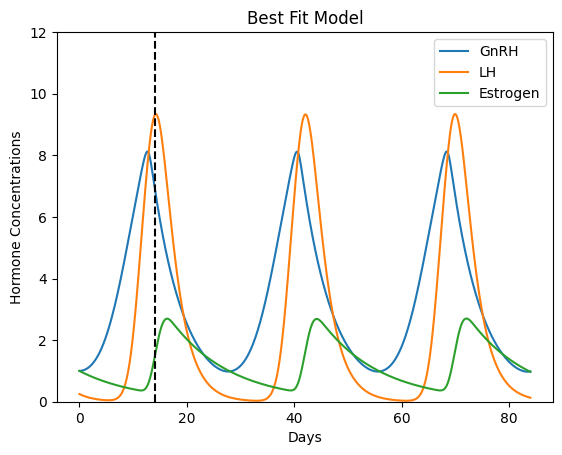

In [48]:
model = ControlMenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 3*28), resolution=1000)
sol = model.simulate([0, 0, 0])
model.plot(sol, plot_day_14=True, ylim=(0, 12), title="Best Fit Model")
plt.savefig("figures/best_fit.pdf")